## Assignment 2: $k$ Nearest Neighbor

### Do any four.

Q1,2,3,& 6

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. Regression predicts a continuous numerical outcome, such as price or temperature, while classification predicts a categorical label, such as group membership or class type. In other words, regression answers “how much?” whereas classification answers “which category?” The evaluation metrics also differ: regression typically uses measures like RMSE, while classification uses metrics like accuracy and confusion matrices.
2. A confusion matrix is a table that compares actual class labels with predicted class labels. It shows how many observations are correctly classified (on the diagonal) and where misclassifications occur (off-diagonal entries). This helps us understand which classes are being confused with one another, providing a more detailed view of performance than overall accuracy alone.
3. Accuracy is the proportion of correct predictions out of the total number of predictions made. While easy to interpret, accuracy can be misleading when classes are imbalanced or when certain errors are more costly than others. It does not show which specific classes are misclassified or how severe different types of mistakes may be.
4. RMSE measures the average magnitude of prediction errors in a regression model by taking the square root of the average squared differences between predicted and actual values. It penalizes larger errors more heavily because the errors are squared before averaging. A lower RMSE indicates that predictions are, on average, closer to the true values.
5. Overfitting occurs when a model is too complex and captures noise in the training data, resulting in strong training performance but poor generalization to new data. Underfitting occurs when a model is too simple to capture the underlying structure of the data, leading to poor performance on both training and test data. The goal is to balance model complexity so that it generalizes well.
6. Splitting the data into training and testing sets allows us to evaluate how well the model performs on unseen data rather than the data it was trained on. Choosing k based on test-set accuracy (for classification) or RMSE (for regression) helps ensure that the selected model generalizes well rather than simply fitting noise in the training set. This process reduces the risk of overfitting and improves reliability when the model is applied in practice.
7. Reporting a class label provides a clear and simple prediction, making it easy to interpret and act upon. However, it does not communicate uncertainty. Reporting probabilities over class labels provides more information about confidence and uncertainty, which is especially valuable in high-stakes decisions. The tradeoff is that probabilities can be harder to interpret and require choosing a threshold for final decisions.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [2]:
import pandas as pd

df = pd.read_csv("land_mines.csv")

print(df.head())
print("Shape:", df.shape)

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
Shape: (338, 4)


The dataset contains 338 observations and 4 variables: three predictors (voltage, height, and soil) and one target variable (mine_type). The target variable takes five possible class values (1–5), which are fairly evenly distributed.

In [3]:
print("Mine type counts:")
print(df["mine_type"].value_counts())

print("\nMine type proportions:")
print(df["mine_type"].value_counts(normalize=True))

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Mine type proportions:
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


Each mine type represents roughly 20% of the data, so the classes are balanced and class imbalance is not a concern.

In [4]:
print(df[["voltage","height","soil"]].describe())

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


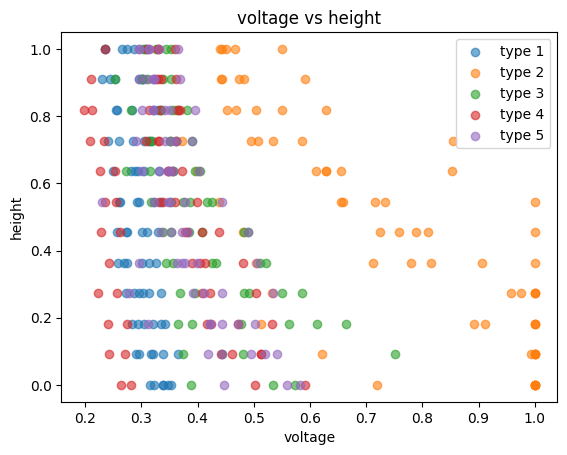

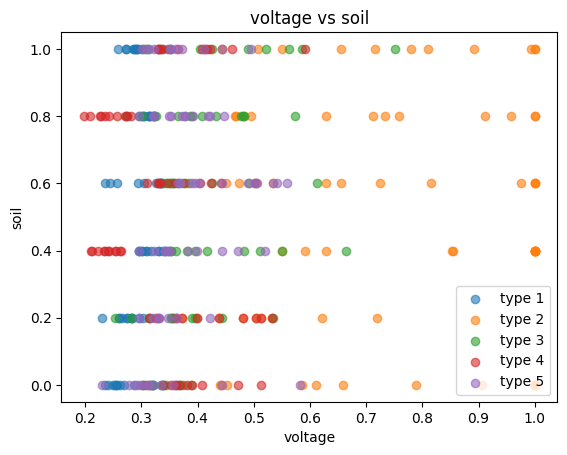

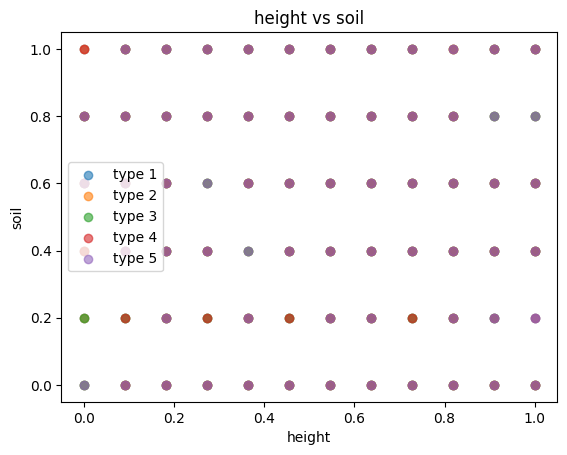

In [6]:
import matplotlib.pyplot as plt

pairs = [("voltage","height"), ("voltage","soil"), ("height","soil")]

for x, y in pairs:
    plt.figure()
    for c in sorted(df["mine_type"].unique()):
        sub = df[df["mine_type"] == c]
        plt.scatter(sub[x], sub[y], label=f"type {c}", alpha=0.6)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.legend()
    plt.show()

The summary statistics show that voltage, height, and soil are scaled between 0 and 1 and exhibit reasonable spread across their ranges. However, the scatterplots reveal substantial overlap between several mine types, particularly types 3, 4, and 5. This overlap suggests that the three predictors do not clearly separate all classes, which likely contributes to the model’s moderate accuracy.

In [7]:
from sklearn.model_selection import train_test_split

X = df[["voltage","height","soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

The data were split evenly while preserving class proportions in both sets to ensure that each mine type appears in training and test data.

In [9]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 41, 2))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best k:", best_k)
print("Best test accuracy:", best_accuracy)

Best k: 1
Best test accuracy: 0.46153846153846156


The value of k was chosen by evaluating test accuracy across candidate values and selecting the k that maximized performance. The best value was k = 1, producing a test accuracy of approximately 46%.

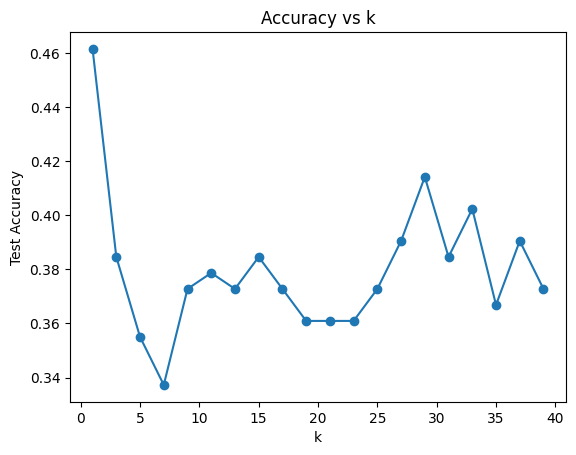

In [10]:
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_s, y_train)

preds = best_model.predict(X_test_s)

print("Final Test Accuracy:", accuracy_score(y_test, preds))

cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, preds))

Final Test Accuracy: 0.46153846153846156

Confusion Matrix:
 [[21  0  4  4  7]
 [ 0 32  0  3  0]
 [ 8  0  7 10  8]
 [ 7  5  4 11  6]
 [ 7  0  9  9  7]]

Classification Report:
               precision    recall  f1-score   support

           1       0.49      0.58      0.53        36
           2       0.86      0.91      0.89        35
           3       0.29      0.21      0.25        33
           4       0.30      0.33      0.31        33
           5       0.25      0.22      0.23        32

    accuracy                           0.46       169
   macro avg       0.44      0.45      0.44       169
weighted avg       0.45      0.46      0.45       169



Mine type 2 is classified very accurately, while types 3, 4, and 5 are frequently confused with one another. This indicates that these types share similar feature profiles.

In practice, this model should be used as a decision-support tool rather than a final authority. Because certain mine types are frequently misclassified, predictions should be handled conservatively, especially in cases where safety risks differ across types. The model may help guide prioritization, but expert verification would still be necessary in high-risk environments.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [12]:
import pandas as pd

df = pd.read_csv("USA_cars_datasets.csv")

df = df[["price","year","mileage"]]

print(df.head())
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Shape: (2499, 3)

Missing values:
 price      0
year       0
mileage    0
dtype: int64


The dataset contains 2,499 observations and three variables: price (the target variable), and year and mileage (the predictors). The head of the data confirms that price is measured in dollars, year represents the model year of the vehicle, and mileage represents total miles driven. There are no missing values in any of the variables, so no additional cleaning or imputation is required before modeling.

In [13]:
from sklearn.preprocessing import MinMaxScaler

X = df[["year","mileage"]]
y = df["price"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

kNN is distance-based, so scaling ensures that year and mileage contribute equally to the distance calculation.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

80% of the data are used to train the model, while 20% are reserved for evaluating performance and selecting the best k.

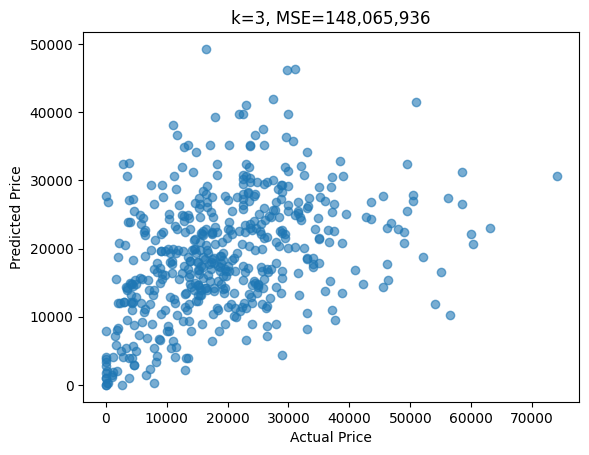

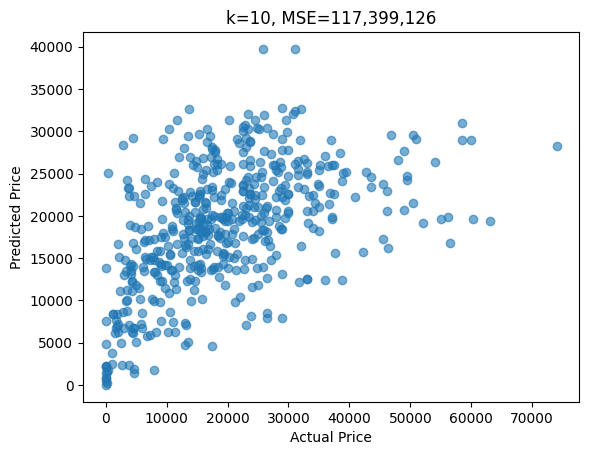

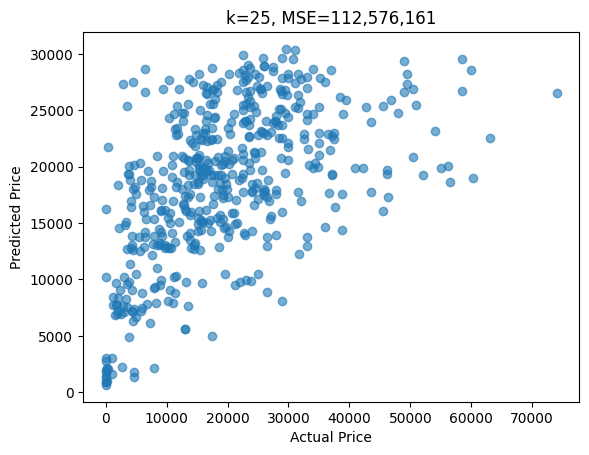

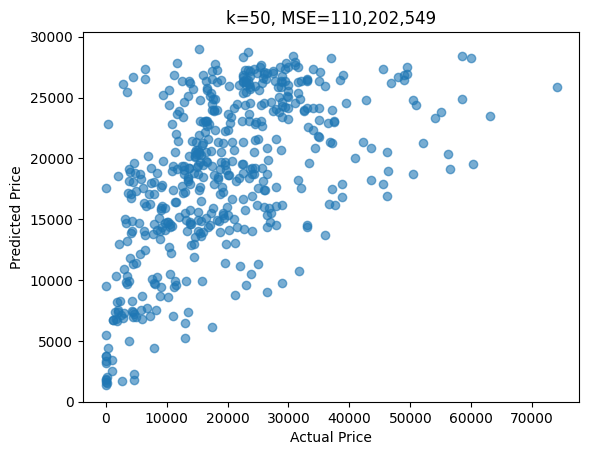

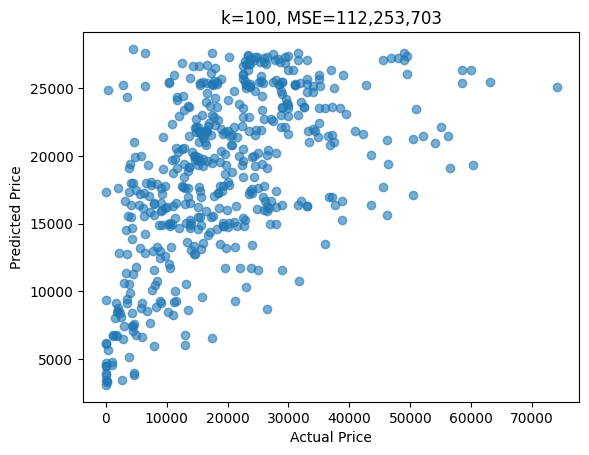

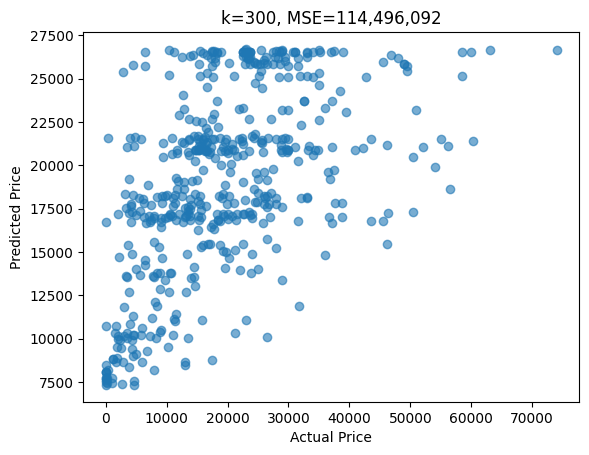

MSE Results:
k=3: MSE=148,065,936
k=10: MSE=117,399,126
k=25: MSE=112,576,161
k=50: MSE=110,202,549
k=100: MSE=112,253,703
k=300: MSE=114,496,092


In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = [3,10,25,50,100,300]
results = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)

    results.append((k, mse))

    plt.figure()
    plt.scatter(y_test, preds, alpha=0.6)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k={k}, MSE={mse:,.0f}")
    plt.show()

print("MSE Results:")
for k, mse in results:
    print(f"k={k}: MSE={mse:,.0f}")

The mean squared error decreases substantially as k increases from 3 to 50, reaching its lowest value at k = 50. After k = 50, the MSE begins to increase again. This indicates that small values of k, such as 3, likely overfit the training data by reacting too strongly to local noise, resulting in higher test error. As k increases, the model becomes smoother and generalizes better, reducing error. However, when k becomes too large (such as 100 or 300), the model begins to underfit by averaging across too many observations, causing predictions to move closer to the overall mean price and increasing error again. Therefore, k = 50 provides the best balance between overfitting and underfitting for this dataset.

As k increases from 3 to 50, the scatterplots of predicted versus actual price become tighter around the diagonal line, indicating improved predictive accuracy. When k is very small (k=3), predictions vary widely and may show extreme values, reflecting overfitting. When k becomes very large (k=300), predictions cluster toward the center of the price distribution, forming a horizontal band and reflecting underfitting. The optimal value k=50 produces the best balance, where predictions follow the overall structure of the data without excessive noise.

In [16]:
best_k, best_mse = min(results, key=lambda x: x[1])

print("Optimal k:", best_k)
print("Lowest MSE:", best_mse)

Optimal k: 50
Lowest MSE: 110202549.3014296


The value of
𝑘 that minimizes mean squared error is
k=50, with a lowest MSE of approximately 110,202,549. As k increases from 3 to 50, the MSE steadily decreases, indicating improved generalization performance. Small values of k, such as 3, likely overfit the data by reacting too strongly to local noise, resulting in higher test error. After
k=50, the MSE begins to increase again, suggesting underfitting as the model averages across too many neighbors and loses important structure in the relationship between price, year, and mileage. Thus,
k=50 provides the best balance between overfitting and underfitting for this dataset.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [17]:
import pandas as pd

df = pd.read_csv("airbnb_hw.csv")

df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]

print(df.head())
print("Shape:", df.shape)

   Review Scores Rating Price  Beds
0                   NaN   145   1.0
1                   NaN    37   1.0
2                   NaN    28   1.0
3                   NaN   199   3.0
4                  96.0   549   3.0
Shape: (30478, 3)


The dataset contains 30,478 observations and three variables: Review Scores Rating, Price, and Beds. The output confirms that many listings have missing values for Review Scores Rating, which is expected given that only 22,155 ratings are available. These missing ratings will be imputed using a k-nearest neighbor regression model based on Price and Beds.

In [18]:
missing = df.loc[df["Review Scores Rating"].isnull()].copy()
complete = df.loc[~df["Review Scores Rating"].isnull()].copy()

print("Missing ratings:", missing.shape[0])
print("Complete cases:", complete.shape[0])

Missing ratings: 8323
Complete cases: 22155


There are 8,323 listings with missing review scores and 22,155 listings with observed ratings. The rows with missing ratings are set aside and will be predicted later, while the 22,155 complete cases will be used to train the k-nearest neighbor regression model.

In [19]:
complete = complete.dropna(axis=0, how='any')
print("Shape after dropping any remaining NA:", complete.shape)

Shape after dropping any remaining NA: (22111, 3)


After removing any remaining missing values in the predictors, 22,111 complete observations remain. A small number of listings with ratings had missing values in either Price or Beds and were therefore excluded to ensure the model is trained only on fully observed data.

In [22]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

k_values = list(range(1, 51, 2))  # try odd values from 1 to 49
mse_list = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_list.append(mse)

best_k = k_values[np.argmin(mse_list)]
best_mse = min(mse_list)

print("Best k:", best_k)
print("Lowest MSE:", best_mse)

Best k: 49
Lowest MSE: 109931222.53539108


The optimal value of k is 49, which produces the lowest test-set mean squared error of approximately 109,931,223. As k increases from very small values, the model becomes less sensitive to local noise and generalizes better, reducing error. Extremely small values of k would likely overfit by relying too heavily on individual nearby observations, while very large values would underfit by averaging across too many listings and shrinking predictions toward the overall mean. The selected value k=49 represents a balance between overfitting and underfitting.

In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
X = complete[["Price", "Beds"]]
y = complete["Review Scores Rating"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_scaled, y)

print("Fit complete. X_scaled rows:", X_scaled.shape[0], "y rows:", y.shape[0])

Fit complete. X_scaled rows: 22111 y rows: 22111


In [27]:
missing = df.loc[df["Review Scores Rating"].isnull(), ["Review Scores Rating","Price","Beds"]].copy()
print("Missing ratings rows (raw):", missing.shape[0])
print(missing.head())

Missing ratings rows (raw): 8323
    Review Scores Rating Price  Beds
0                    NaN   145   1.0
1                    NaN    37   1.0
2                    NaN    28   1.0
3                    NaN   199   3.0
13                   NaN    68   1.0


In [28]:
print("Missing Price count:", missing["Price"].isna().sum())
print("Missing Beds count:", missing["Beds"].isna().sum())

Missing Price count: 0
Missing Beds count: 41


In [29]:
missing_pred = missing.dropna(subset=["Price","Beds"]).copy()
print("Rows available to impute:", missing_pred.shape[0])

Rows available to impute: 8282


In [34]:
import pandas as pd
complete["Price"] = (
    complete["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)
complete["Price"] = pd.to_numeric(complete["Price"], errors="coerce")
complete["Beds"] = pd.to_numeric(complete["Beds"], errors="coerce")
complete["Review Scores Rating"] = pd.to_numeric(complete["Review Scores Rating"], errors="coerce")
complete = complete.dropna(subset=["Price","Beds","Review Scores Rating"]).copy()

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

X = complete[["Price","Beds"]]
y = complete["Review Scores Rating"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_scaled, y)

print("Complete cleaned shape:", complete.shape)
print("Dtypes:\n", complete.dtypes)

Complete cleaned shape: (22111, 3)
Dtypes:
 Review Scores Rating    float64
Price                     int64
Beds                    float64
dtype: object


In [35]:

missing = df.loc[df["Review Scores Rating"].isnull(), ["Review Scores Rating","Price","Beds"]].copy()

missing["Price"] = (
    missing["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)
missing["Price"] = pd.to_numeric(missing["Price"], errors="coerce")
missing["Beds"] = pd.to_numeric(missing["Beds"], errors="coerce")

missing_pred = missing.dropna(subset=["Price","Beds"]).copy()
print("Rows available to impute:", missing_pred.shape[0])

X_missing = missing_pred[["Price","Beds"]]
X_missing_scaled = scaler.transform(X_missing)

missing_pred["Imputed Rating"] = best_model.predict(X_missing_scaled)

print("Imputed rows:", missing_pred.shape[0])
missing_pred.head()

Rows available to impute: 8282
Imputed rows: 8282


,Review Scores Rating,Price,Beds,Imputed Rating
0,NaN,145,1.0,94.897959
1,NaN,37,1.0,89.163265
2,NaN,28,1.0,84.530612
3,NaN,199,3.0,89.346939
13,NaN,68,1.0,92.081633


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

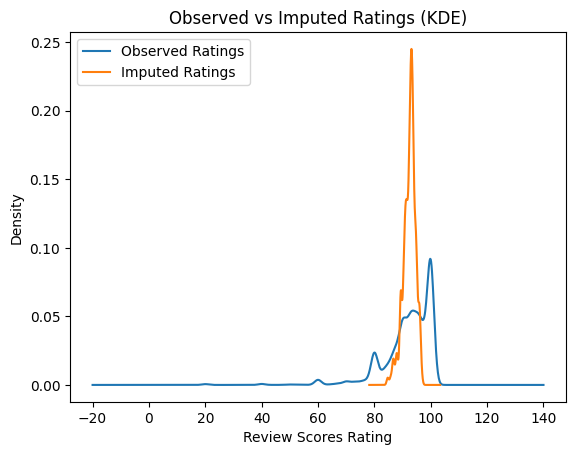

In [36]:
import matplotlib.pyplot as plt

plt.figure()

complete["Review Scores Rating"].plot(kind="kde", label="Observed Ratings")
missing_pred["Imputed Rating"].plot(kind="kde", label="Imputed Ratings")

plt.legend()
plt.xlabel("Review Scores Rating")
plt.title("Observed vs Imputed Ratings (KDE)")
plt.show()

The kernel density plot shows that the imputed ratings are much more concentrated around the mean compared to the observed ratings. While the observed ratings display noticeable variability across a wider range of values, the imputed ratings form a sharp peak in the high 80s to low 90s. This occurs because kNN regression averages nearby observations, which compresses variation and pulls predictions toward central values. As a result, the imputed ratings underestimate the true variability present in the observed data. Although the general location of the distribution is preserved, the imputed values are considerably smoother and less dispersed.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)